In [62]:
from pathlib import Path
from pandas import read_pickle
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

measures_path = Path('results_og_all_El espejo', 'measures')
measures_correlation_path = Path('results_og_all_El espejo', 'measures_correlation')
items = list(measures_path.iterdir())
item_subj = {item.name: list(item.iterdir()) for item in items}
measures = ['FFD', 'FPRT', 'TFD', 'SFD', 'SPRT', 'RRT']
n_bins = 10

In [64]:
def binarize_measure(subj, measure):
    measure_mask = subj[measure] > 0
    subj = subj.astype({measure: np.float32})
    subj.loc[:, measure] = pd.qcut(subj[measure][measure_mask], n_bins, labels=False,
                                   duplicates='drop')
    subj.loc[:, measure] = subj[measure].fillna(0)
    subj.loc[:, measure] = subj[measure].astype(np.int32)

def binarize_subjects_measures(subjects, measures):
    binarized_subjects = []
    for subj in subjects:
        subj = subj[~subj['excluded']]
        for i, measure in enumerate(measures):
            binarize_measure(subj, measure)
        binarized_subjects.append(subj)
    return binarized_subjects

def compute_correlation_matrices(subjects, all_measures):
    correlation_matrices = []
    for measure in all_measures:
        correlation_matrix = np.zeros((len(subjects), len(subjects)))
        for i, subj1 in enumerate(subjects):
            for j, subj2 in enumerate(subjects):
                if i != j:
                    correlation_matrix[i, j] = spearmanr(subj1[measure], subj2[measure])[0]
        correlation_matrices.append(correlation_matrix)
    return correlation_matrices

def plot_correlation_matrices(correlation_matrices, all_measures, title, min_val=0.0, max_val=1.0, filename='global_avg'): 
    fig, axes = plt.subplots(2, 3, figsize=(9, 6), sharex=True, sharey=True)
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    
    for i, measure in enumerate(all_measures):
        sns.heatmap(correlation_matrices[i], ax=axes[i // 3, i % 3], cmap='coolwarm', center=0,
                    vmin=min_val, vmax=max_val, cbar=(i == 0), cbar_ax=cbar_ax if i == 0 else None)
        axes[i // 3, i % 3].set_title(measure)
        axes[i // 3, i % 3].tick_params(axis='y', rotation=0)
        axes[i // 3, i % 3].tick_params(axis='x', rotation=0)
    
    if title:
        fig.suptitle(title + f' - {n_bins} bins')
    plt.tight_layout(rect=[0, 0, 0.9, 1])  # Leave space for colorbar
    measures_correlation_path.mkdir(parents=True, exist_ok=True)
    fig.savefig(measures_correlation_path / f'{filename}.png', dpi=300)

In [65]:
items_correlation_matrices = {}
for item in item_subj:
    subjects = [read_pickle(subj) for subj in item_subj[item]]
    binarized_subjects = binarize_subjects_measures(subjects, measures)
    correlation_matrices = compute_correlation_matrices(binarized_subjects, measures)
    items_correlation_matrices[item] = correlation_matrices

/tmp/ipykernel_12860/427260358.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # Leave space for colorbar


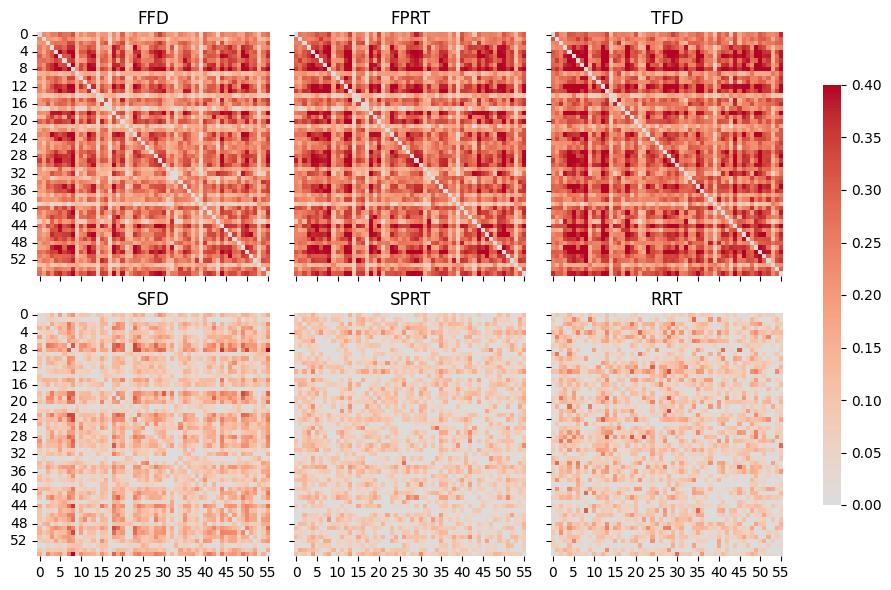

In [67]:
max_subjects = 56
n_items_used = 1
avg_correlation_matrices = [np.zeros((max_subjects, max_subjects)) for _ in measures]
for item in items_correlation_matrices:
    correlation_matrices = items_correlation_matrices[item]
    for i in range(len(measures)):
        if correlation_matrices[i].shape[0] < max_subjects:
            continue
        if correlation_matrices[i].shape[0] > max_subjects:
            correlation_matrices[i] = correlation_matrices[i][:max_subjects, :max_subjects]
        avg_correlation_matrices[i] += correlation_matrices[i] / n_items_used
plot_correlation_matrices(avg_correlation_matrices, measures, title=None, min_val=0.0, max_val=0.4)

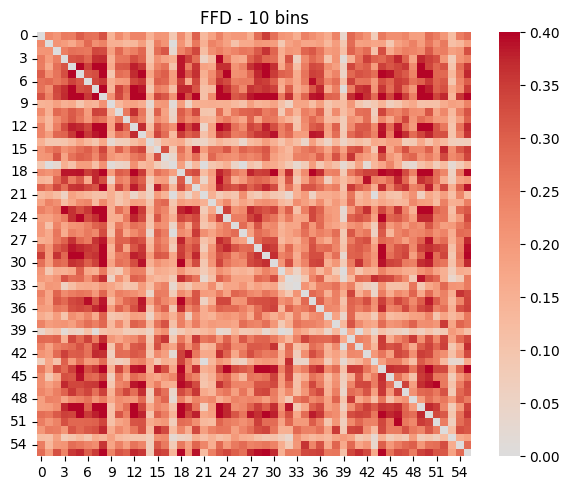

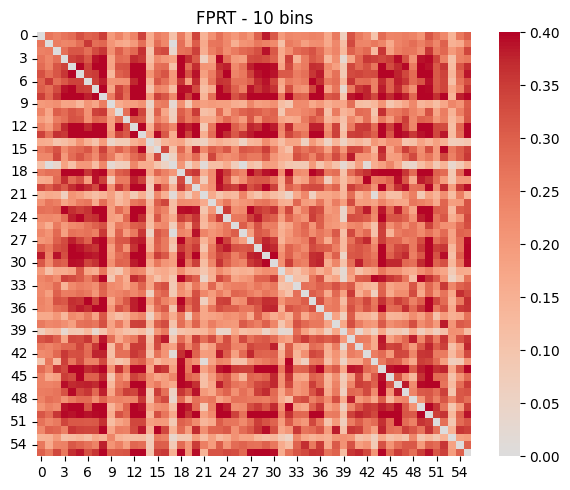

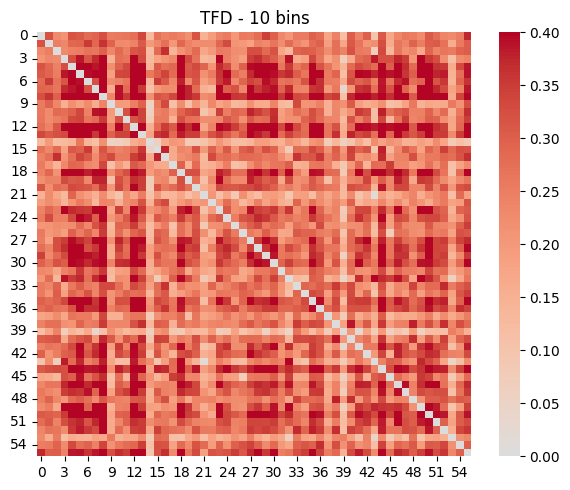

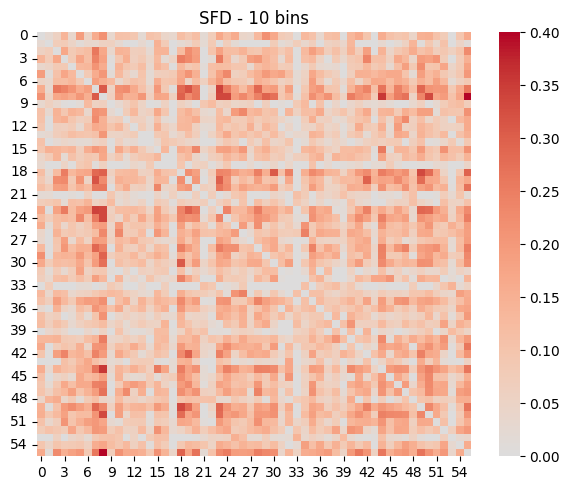

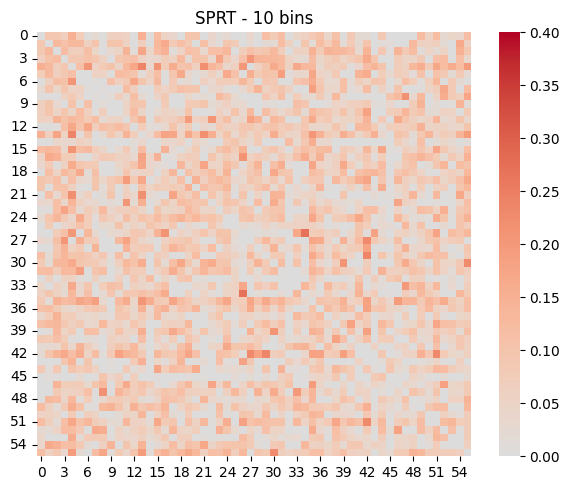

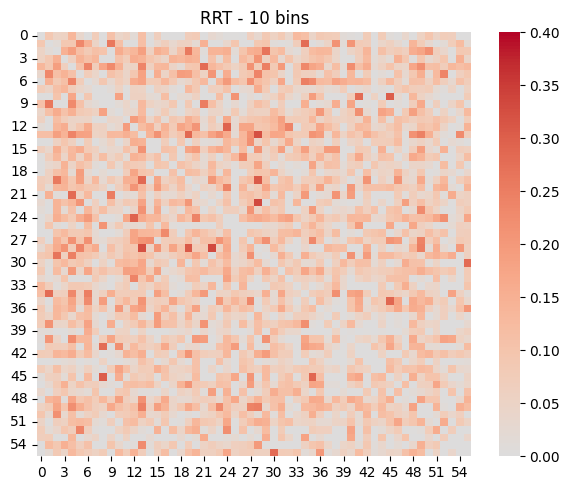

In [68]:
def plot_one_heatmap_per_metric(correlation_matrices, all_measures,
                                min_val=0.0, max_val=1.0,
                                out_dir=measures_correlation_path,
                                prefix='avg_corr'):
    out_dir.mkdir(parents=True, exist_ok=True)

    for i, measure in enumerate(all_measures):
        fig, ax = plt.subplots(figsize=(6, 5))

        sns.heatmap(
            correlation_matrices[i],
            ax=ax,
            cmap='coolwarm',
            center=0,
            vmin=min_val,
            vmax=max_val,
            cbar=True
        )

        ax.set_title(f'{measure} - {n_bins} bins')
        ax.tick_params(axis='x', rotation=0)
        ax.tick_params(axis='y', rotation=0)

        plt.tight_layout()
        plt.show()
        fig.savefig(out_dir / f'{prefix}_{measure}.png', dpi=300)
        plt.close(fig)
        
plot_one_heatmap_per_metric(
    avg_correlation_matrices,
    measures,
    min_val=0.0,
    max_val=0.4
)

In [69]:
first_item = list(item_subj.keys())[0]
subject_names = [subj.stem for subj in item_subj[first_item]]

for i, name in enumerate(subject_names):
    print(f"{i} → {name}")

0 → sub-067
1 → sub-054
2 → sub-078
3 → sub-046
4 → sub-097
5 → sub-079
6 → sub-028
7 → sub-089
8 → sub-109
9 → sub-070
10 → sub-111
11 → sub-073
12 → sub-001
13 → sub-095
14 → sub-012
15 → sub-052
16 → sub-094
17 → sub-088
18 → sub-044
19 → sub-009
20 → sub-041
21 → sub-024
22 → sub-016
23 → sub-112
24 → sub-058
25 → sub-018
26 → sub-048
27 → sub-087
28 → sub-091
29 → sub-083
30 → sub-065
31 → sub-077
32 → sub-039
33 → sub-053
34 → sub-075
35 → sub-060
36 → sub-103
37 → sub-105
38 → sub-064
39 → sub-010
40 → sub-034
41 → sub-002
42 → sub-085
43 → sub-021
44 → sub-096
45 → sub-027
46 → sub-006
47 → sub-066
48 → sub-101
49 → sub-042
50 → sub-003
51 → sub-107
52 → sub-098
53 → sub-086
54 → sub-013
55 → sub-068


In [70]:
item_subj = {
    item.name: sorted(item.iterdir(), key=lambda x: x.stem)
    for item in items
}
def correlation_matrices_to_df(correlation_matrices, subject_names, measures):
    rows = []

    for m_idx, measure in enumerate(measures):
        matrix = correlation_matrices[m_idx]

        for i in range(len(subject_names)):
            for j in range(len(subject_names)):
                if i >= j:
                    continue  # avoid duplicates + diagonal

                rows.append({
                    "subject_1": subject_names[i],
                    "subject_2": subject_names[j],
                    "measure": measure,
                    "correlation": matrix[i, j]
                })

    return pd.DataFrame(rows)

corr_df = correlation_matrices_to_df(
    avg_correlation_matrices,
    subject_names,
    measures
)

corr_df

,subject_1,subject_2,measure,correlation
0,sub-067,sub-054,FFD,0.230163
1,sub-067,sub-078,FFD,0.206412
2,sub-067,sub-046,FFD,0.255660
3,sub-067,sub-097,FFD,0.252057
4,sub-067,sub-079,FFD,0.303572
...,...,...,...,...
9235,sub-098,sub-013,RRT,-0.044551
9236,sub-098,sub-068,RRT,-0.038782
9237,sub-086,sub-013,RRT,-0.121456
9238,sub-086,sub-068,RRT,0.038757


In [72]:
corr_df.to_csv('normal.csv', index=False)